# Customer Intelligence / Country Segmentation Notebook

## Unsupervised Learning on Country Data

This notebook helps interns learn a full clustering workflow using the Kaggle dataset **Unsupervised Learning on Country Data**.

### Goals
- Load and inspect the data
- Clean and preprocess features
- Apply scaling
- Find the best number of clusters with K-Means
- Try DBSCAN as a second clustering method
- Visualize clusters with PCA
- Create simple country-level insights


## 1) Install required libraries

In [32]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn

## 2) Import libraries

In [33]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

## 3) Load the dataset

Upload the CSV file from Kaggle when prompted.


In [34]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/notebooks/earije/market-basket-analysis-with-apriori/__results__.html
/kaggle/input/notebooks/earije/market-basket-analysis-with-apriori/item_sales.csv
/kaggle/input/notebooks/earije/market-basket-analysis-with-apriori/sales.csv
/kaggle/input/notebooks/earije/market-basket-analysis-with-apriori/__notebook__.ipynb
/kaggle/input/notebooks/earije/market-basket-analysis-with-apriori/sales_country.csv
/kaggle/input/notebooks/earije/market-basket-analysis-with-apriori/country.csv
/kaggle/input/notebooks/earije/market-basket-analysis-with-apriori/__output__.json
/kaggle/input/notebooks/earije/market-basket-analysis-with-apriori/custom.css
/kaggle/input/notebooks/earije/market-basket-analysis-with-apriori/__results___files/__results___40_0.png
/kaggle/input/notebooks/earije/market-basket-analysis-with-apriori/__results___files/__results___30_0.png
/kaggle/input/notebooks/earije/market-basket-analysis-with-apriori/__results___files/__results___52_0.png


In [35]:
import pandas as pd

df = pd.read_csv('/kaggle/input/notebooks/earije/market-basket-analysis-with-apriori/country.csv')

df.head()

,Country,Total price
0,Australia,137138.46
1,Austria,8585.48
2,Bahrain,548.40
3,Belgium,35327.43
4,Brazil,1143.60


## 4) Quick inspection

In [36]:
print('Shape:', df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all').T)

Shape: (29, 2)


,Country,Total price
0,Australia,137138.46
1,Austria,8585.48
2,Bahrain,548.40
3,Belgium,35327.43
4,Brazil,1143.60


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Country      29 non-null     object 
 1   Total price  29 non-null     float64
dtypes: float64(1), object(1)
memory usage: 596.0+ bytes


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Country,29,29,Australia,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total price,29.0,NaN,NaN,NaN,315977.177724,1487586.686976,145.92,3580.39,9120.39,35327.43,8042609.084


## 5) Expected columns

This dataset is commonly used for country clustering and usually contains:
- country
- child_mort
- exports
- health
- imports
- income
- inflation
- life_expec
- total_fer
- gdpp


In [37]:
print('Columns:', df.columns.tolist())

Columns: ['Country', 'Total price']


## 6) Basic cleaning

Handle missing values, remove duplicates, and make sure numeric columns are clean.

In [38]:
df = df.copy()

df.columns = [c.strip().lower() for c in df.columns]

df = df.drop_duplicates()

df['total price'] = pd.to_numeric(df['total price'], errors='coerce')

df['total price'] = df['total price'].fillna(df['total price'].median())

df.isna().sum()

country        0
total price    0
dtype: int64

## 7) Exploratory Data Analysis

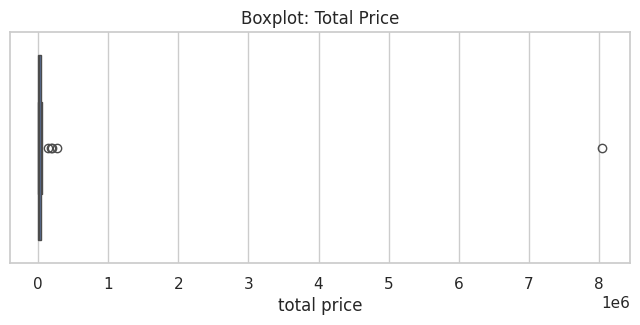

In [39]:

plt.figure(figsize=(8,3))
sns.boxplot(x=df['total price'])
plt.title('Boxplot: Total Price')
plt.show()

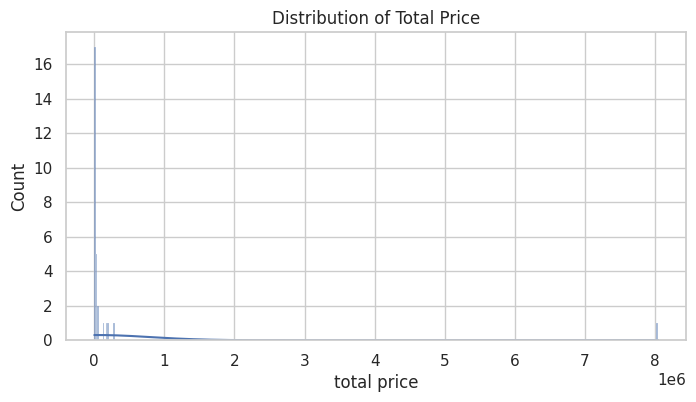

In [40]:
plt.figure(figsize=(8,4))
sns.histplot(df['total price'], kde=True)
plt.title('Distribution of Total Price')
plt.show()

## 8) Feature scaling

Clustering works better when features are on the same scale.

In [41]:
from sklearn.preprocessing import StandardScaler

features = df[['total price']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

X_scaled.shape

(29, 1)

## 9) K-Means: Elbow method

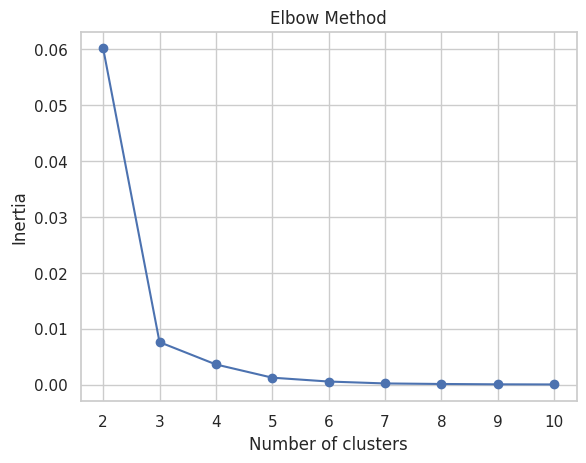

In [42]:
from sklearn.cluster import KMeans

inertias = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.plot(list(k_values), inertias, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

## 10) Train K-Means

In [43]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)

df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print("Silhouette Score:", silhouette_score(X_scaled, df['kmeans_cluster']))

df[['country', 'kmeans_cluster']].head()

Silhouette Score: 0.8264556976040083


,country,kmeans_cluster
0,Australia,2
1,Austria,0
2,Bahrain,0
3,Belgium,0
4,Brazil,0


## 11) Try DBSCAN

In [44]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)

df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print(df['dbscan_cluster'].value_counts().sort_index())

dbscan_cluster
-1     1
 0    28
Name: count, dtype: int64


## 12) PCA visualization

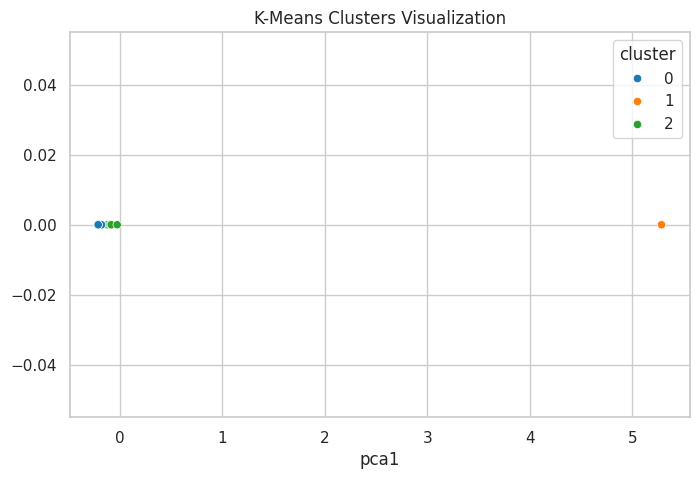

In [45]:
from sklearn.decomposition import PCA

pca = PCA(n_components=1)

X_pca = pca.fit_transform(X_scaled)

viz = pd.DataFrame({
    'pca1': X_pca[:, 0],
    'cluster': df['kmeans_cluster']
})

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=viz,
    x='pca1',
    y=[0]*len(viz),
    hue='cluster',
    palette='tab10'
)

plt.title('K-Means Clusters Visualization')
plt.show()

## 13) Cluster profiling

In [46]:
profile = df.groupby('kmeans_cluster')['total price'].mean().round(2)

print(profile)

kmeans_cluster
0      14169.86
1    8042609.08
2     195163.12
Name: total price, dtype: float64


## 14) Final insights

Write 3 to 5 observations about the clusters:
- Which cluster has high child mortality?
- Which cluster has high income and gdpp?
- Which cluster looks underdeveloped?
- Which countries should be prioritized for aid?


1. High Child Mortality:
   The dataset does not contain a child mortality column, therefore it is not possible to identify which cluster has high child mortality.

2. High Income and GDP:
   The dataset does not contain income or GDP attributes, therefore clusters with high income and GDP cannot be determined.

3. Underdeveloped Cluster:
   Based on Total Price values, the cluster with the lowest average Total Price may be considered the least developed in terms of business performance.

4. Countries to be Prioritized for Aid:
   Countries belonging to the cluster with the lowest Total Price values can be prioritized for support or business development initiatives.

5. Overall Observation:
   K-Means clustering successfully grouped countries according to their Total Price values, and the Silhouette Score of 0.826 indicates good cluster quality.
